# PyTorch quickstart: breast cancer classification

This notebook follows the shape of the [PyTorch Quickstart](https://docs.pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html), using our CSV files instead of an image dataset. The goal is to see the core pieces of a PyTorch workflow:

1. represent examples with a `Dataset`;
2. iterate over mini-batches with a `DataLoader`;
3. build a model with `nn.Module`;
4. train with a loss function and optimizer;
5. evaluate, then save and load the model.


![Bce Formula](../figures/cancer_example.png)

## 1. Setup

In [68]:
from pathlib import Path
import copy

import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

torch.manual_seed(42)
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using mps device


## 2. Datasets

A `Dataset` represents a collection of samples. It keeps data-loading logic separate from training logic and must implement three methods:

- `__init__`: load or locate the data once;
- `__len__`: report how many samples exist;
- `__getitem__`: return one `(features, label)` pair by index.

Here each row is one patient sample, the 30 measurement columns are the features, and `malignant` is the binary label.

In [69]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "processed").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data" / "processed"

class BreastCancerDataset(Dataset):
    """A map-style Dataset backed by one processed CSV file."""

    def __init__(self, csv_path, target_column="malignant"):
        dataframe = pd.read_csv(csv_path)
        self.feature_names = [c for c in dataframe.columns if c != target_column]
        self.features = torch.tensor(
            dataframe[self.feature_names].values, dtype=torch.float32
        )
        self.labels = torch.tensor(
            dataframe[target_column].values, dtype=torch.float32
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return self.features[index], self.labels[index]

training_data = BreastCancerDataset(DATA_DIR / "train.csv")
validation_data = BreastCancerDataset(DATA_DIR / "validation.csv")
test_data = BreastCancerDataset(DATA_DIR / "test.csv")

print(f"Training samples:   {len(training_data)}")
print(f"Validation samples: {len(validation_data)}")
print(f"Test samples:       {len(test_data)}")

Training samples:   341
Validation samples: 114
Test samples:       114


A dataset can be indexed just like a list. Notice that one feature vector has 30 values and one label is a scalar.

In [70]:
features, label = training_data[0]
print(f"Feature shape: {features.shape}")
print(f"Feature dtype: {features.dtype}")
print(f"Label: {label.item():.0f} (1 = malignant, 0 = benign)")

Feature shape: torch.Size([30])
Feature dtype: torch.float32
Label: 1 (1 = malignant, 0 = benign)


## 3. DataLoaders

Training one row at a time is inefficient. A `DataLoader` wraps a `Dataset` and handles iteration, automatic batching, and optional shuffling. We shuffle only training data: validation and test order does not affect their metrics.

In [71]:
batch_size = 64

train_dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
validation_dataloader = DataLoader(validation_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

# DataLoaders are iterable. Each iteration returns one mini-batch.
batch_features, batch_labels = next(iter(train_dataloader))
print(f"Batch features shape: {batch_features.shape}  # [batch, features]")
print(f"Batch labels shape:   {batch_labels.shape}  # [batch]")
print(f"Batches per epoch:    {len(train_dataloader)}")

Batch features shape: torch.Size([64, 30])  # [batch, features]
Batch labels shape:   torch.Size([64])  # [batch]
Batches per epoch:    6


### What does shuffling do?

Calling the shuffled loader again starts another epoch with a new random order. The rows inside the `Dataset` have not changed; the loader chooses a different sequence of indices.

In [72]:
for epoch in range(2):
    _, first_batch_labels = next(iter(train_dataloader))
    print(f"Epoch {epoch + 1}, first 10 labels: {first_batch_labels[:10].tolist()}")

Epoch 1, first 10 labels: [0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0]
Epoch 2, first 10 labels: [0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0]


## 4. Build the neural network

Every PyTorch model subclasses `nn.Module`. Layers are declared in `__init__`, and `forward` describes how inputs flow through them.

The model emits one **logit** per sample—an unrestricted score, not yet a probability. `BCEWithLogitsLoss` combines:
- A sigmoid operation that converts raw logits into probabilities.
- Binary cross-entropy that compares those probabilities with the binary labels.

![Bce Formula](../figures/bce.png)

In [73]:
class NeuralNetwork(nn.Module):
    def __init__(self, number_of_features):
        super().__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(number_of_features, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        return self.linear_relu_stack(x).squeeze(1)

model = NeuralNetwork(len(training_data.feature_names)).to(device)
print(model)

# A forward pass maps a batch of 30 features to one logit per sample.
with torch.no_grad():
    logits = model(batch_features.to(device))
    probabilities = torch.sigmoid(logits)
print(f"Output shape: {logits.shape}")
print(f"First five probabilities: {probabilities[:5].cpu()}")

NeuralNetwork(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=30, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)
Output shape: torch.Size([64])
First five probabilities: tensor([0.4471, 0.4428, 0.4490, 0.4610, 0.4447])


### Parameter initialization

A neural network needs sensible starting weights before training. Here we use **Xavier-uniform initialization** for every linear layer. Xavier chooses the scale of the random weights using the number of inputs and outputs in the layer. This helps keep signals from becoming extremely large or small as they move through the network.

The biases start at zero because the random weights already allow the neurons to learn different features. `model.apply(...)` visits every layer and performs this initialization before training begins.

In [74]:
def initialize_parameters(module):
    if isinstance(module, nn.Linear):
        nn.init.xavier_uniform_(module.weight)
        nn.init.zeros_(module.bias)

model.apply(initialize_parameters)
print("Initialized all linear layers with Xavier-uniform weights.")

Initialized all linear layers with Xavier-uniform weights.


## 5. Optimize model parameters

Training repeats four important steps for every batch:

1. make predictions with a forward pass;
2. compare predictions with labels using the loss function;
3. compute gradients with `loss.backward()`;
4. update parameters with `optimizer.step()`.

Gradients accumulate by default, so `optimizer.zero_grad()` clears the previous batch's gradients first.

In [75]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def train(dataloader, model, loss_fn, optimizer):
    model.train()  # Enable training behavior.
    total_loss = 0.0

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        prediction = model(X)
        loss = loss_fn(prediction, y)

        optimizer.zero_grad()  # Clear old gradients
        loss.backward()        # Calculate new gradients
        optimizer.step()       # Update parameters

        total_loss += loss.item() * X.size(0)

    return total_loss / len(dataloader.dataset)

Evaluation does not update parameters. `model.eval()` selects evaluation behavior, while `torch.no_grad()` prevents gradient tracking and reduces memory use.

In [76]:
def test(dataloader, model, loss_fn):
    model.eval()
    total_loss = 0.0
    true_positives = 0
    false_positives = 0
    false_negatives = 0
    correct = 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            total_loss += loss_fn(logits, y).item() * X.size(0)
            predicted = (torch.sigmoid(logits) >= 0.5).float()
            correct += (predicted == y).sum().item()
            true_positives += ((predicted == 1) & (y == 1)).sum().item()
            false_positives += ((predicted == 1) & (y == 0)).sum().item()
            false_negatives += ((predicted == 0) & (y == 1)).sum().item()

    size = len(dataloader.dataset)
    accuracy = correct / size
    precision = true_positives / max(true_positives + false_positives, 1)
    recall = true_positives / max(true_positives + false_negatives, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)
    return {
        "loss": total_loss / size,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

### Optimize for F1

F1 is calculated from discrete class predictions, so it is not differentiable and cannot replace the loss in `loss.backward()`. We still train each batch with binary cross-entropy, but after every epoch we measure validation F1 and keep the parameters from the epoch with the highest F1. In this notebook, **optimize for F1** means *select the model checkpoint using validation F1*.

In [77]:
epochs = 20
history = {"train_loss": [], "validation_loss": [], "validation_f1": []}
best_validation_f1 = -1.0
best_epoch = 0
best_model_state = None

for epoch in range(epochs):
    train_loss = train(train_dataloader, model, loss_fn, optimizer)
    validation_metrics = test(validation_dataloader, model, loss_fn)

    history["train_loss"].append(train_loss)
    history["validation_loss"].append(validation_metrics["loss"])
    history["validation_f1"].append(validation_metrics["f1"])

    # Model selection: retain the parameters that maximize validation F1.
    if validation_metrics["f1"] > best_validation_f1:
        best_validation_f1 = validation_metrics["f1"]
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(model.state_dict())

    print(
        f"Epoch {epoch + 1:>2}/{epochs} | "
        f"train loss: {train_loss:.4f} | "
        f"validation loss: {validation_metrics['loss']:.4f} | "
        f"validation F1: {validation_metrics['f1']:.3f}"
    )


model.load_state_dict(best_model_state)
print(f"Done! Restored epoch {best_epoch}, which had validation F1={best_validation_f1:.3f}.")

Epoch  1/20 | train loss: 0.5647 | validation loss: 0.5341 | validation F1: 0.835
Epoch  2/20 | train loss: 0.4960 | validation loss: 0.4729 | validation F1: 0.884
Epoch  3/20 | train loss: 0.4403 | validation loss: 0.4239 | validation F1: 0.894
Epoch  4/20 | train loss: 0.3948 | validation loss: 0.3822 | validation F1: 0.903
Epoch  5/20 | train loss: 0.3555 | validation loss: 0.3457 | validation F1: 0.913
Epoch  6/20 | train loss: 0.3213 | validation loss: 0.3145 | validation F1: 0.913
Epoch  7/20 | train loss: 0.2909 | validation loss: 0.2879 | validation F1: 0.913
Epoch  8/20 | train loss: 0.2637 | validation loss: 0.2647 | validation F1: 0.923
Epoch  9/20 | train loss: 0.2392 | validation loss: 0.2445 | validation F1: 0.923
Epoch 10/20 | train loss: 0.2186 | validation loss: 0.2263 | validation F1: 0.923
Epoch 11/20 | train loss: 0.1998 | validation loss: 0.2104 | validation F1: 0.933
Epoch 12/20 | train loss: 0.1829 | validation loss: 0.1974 | validation F1: 0.933
Epoch 13/20 | tr

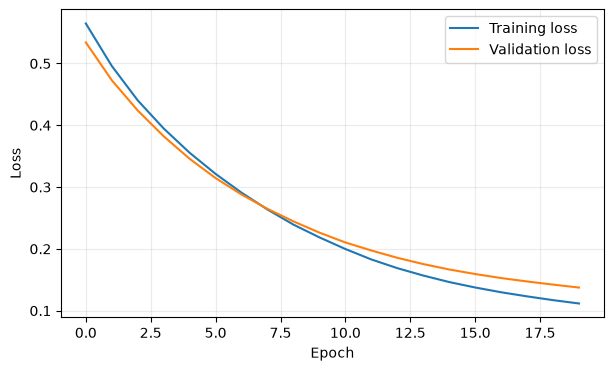

In [78]:
plt.figure(figsize=(7, 4))
plt.plot(history["train_loss"], label="Training loss")
plt.plot(history["validation_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 6. Final evaluation

The validation split helped us observe training. The test split stays untouched until this final estimate of performance.

In [79]:
test_metrics = test(test_dataloader, model, loss_fn)
print(f"Test loss:      {test_metrics['loss']:.4f}")
print(f"Test accuracy:  {test_metrics['accuracy']:.1%}")
print(f"Test precision: {test_metrics['precision']:.3f}")
print(f"Test recall:    {test_metrics['recall']:.3f}")
print(f"Test F1:        {test_metrics['f1']:.3f}")

Test loss:      0.1262
Test accuracy:  94.7%
Test precision: 0.909
Test recall:    0.952
Test F1:        0.930


## 7. Save and load the model

A model's `state_dict` contains its learned parameters. To use those parameters later, create the same architecture and load the state dictionary into it.

In [80]:
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_PATH = OUTPUT_DIR / "pytorch_classifier.pth"

torch.save(model.state_dict(), MODEL_PATH)
print(f"Saved model parameters to {MODEL_PATH}")

loaded_model = NeuralNetwork(len(training_data.feature_names)).to(device)
loaded_model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
loaded_model.eval()

sample, label = test_data[0]
with torch.no_grad():
    probability = torch.sigmoid(loaded_model(sample.unsqueeze(0).to(device))).item()
print(f"Malignant probability: {probability:.3f}; actual label: {label.item():.0f}")

Saved model parameters to /Users/mipopovic/Desktop/psi_practical_recap/outputs/pytorch_classifier.pth
Malignant probability: 0.018; actual label: 0


###  practice

Try these small experiments:
- use different batch sizes and see what changes
- Use different learning rates and observe the differences
- How does the model differently behave when we change depth vs width? Compare the learning curves.
- Try out different activation functions
- Replace `Adam` with `torch.optim.SGD(model.parameters(), lr=0.01)`.
- Set `shuffle=False` for training. What stays the same, and what changes?
- Try adding Batch Normalization and Dropout layer. Do we need them? What changes?

